In [8]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import arviz as az

In [9]:
DATA_PATH = "state_data_TDP_CA_MX_DC_removed.csv"  
df = pd.read_csv(DATA_PATH)
df["week_start_date"] = pd.to_datetime(df["week_start_date"])

In [10]:
contribution_data=pd.read_csv("final_model_contribution_spends_data.csv")
contribution_data['week_start_date']=pd.to_datetime(contribution_data['week_start_date'])

In [11]:
import arviz as az

idata = az.from_netcdf(r"C:\Users\ManojP\Downloads\state_mmm_model_searchdown_ooh_more_tce_removed (2).nc")

posterior = idata.posterior

In [12]:
spends=contribution_data[['week_start_date','state_code', 'Audio_spends', 'Display_spends', 'GSTV_spends', 'OOH_spends',
       'Search_spends', 'Video_spends', 'DM_spends', 'Rewards_spends',
       'ipa_revenue', 'dm_revenue', 'email_revenue', 'sms_revenue',
       'search_revenue', 'sponsorship_revenue', 'ipa_strat_cities_revenue',
       'audio_revenue', 'display_revenue', 'video_revenue', 'gstv_revenue',
       'ooh_revenue',
       
       
       'IPA_spends', 'Strat City_spends']]
df=df.merge(spends,on=['week_start_date','state_code'],how='left')

In [16]:
df.columns

Index(['total_units_sold', 'week_start_date', 'state_code',
       'total_brand_eq_100_pct_amt', 'discount', 'Audio_impressions',
       'Display_impressions', 'GSTV_impressions', 'OOH_impressions',
       'Search_clicks', 'Video_impressions', 'impressions_3p_ipa',
       'impressions_tce', 'dm_sent', 'sms_sent', 'rewards_enrollments',
       'strat_city', 'sponsorship_flag', 'product_launch_flag', 'email_click',
       'wtd_pts_dist_velo_plus', 'wtd_pts_dist_legacy_trifecta',
       'wtd_pts_dist_comp_zyn', 'Audio_spends', 'Display_spends',
       'GSTV_spends', 'OOH_spends', 'Search_spends', 'Video_spends',
       'DM_spends', 'Rewards_spends', 'ipa_revenue', 'dm_revenue',
       'email_revenue', 'sms_revenue', 'search_revenue', 'sponsorship_revenue',
       'ipa_strat_cities_revenue', 'audio_revenue', 'display_revenue',
       'video_revenue', 'gstv_revenue', 'ooh_revenue', 'IPA_spends',
       'Strat City_spends'],
      dtype='object')

In [17]:
spends_new=pd.read_csv("spends_data_new_media.csv")

In [18]:
spends.columns

Index(['week_start_date', 'state_code', 'Audio_spends', 'Display_spends',
       'GSTV_spends', 'OOH_spends', 'Search_spends', 'Video_spends',
       'DM_spends', 'Rewards_spends', 'ipa_revenue', 'dm_revenue',
       'email_revenue', 'sms_revenue', 'search_revenue', 'sponsorship_revenue',
       'ipa_strat_cities_revenue', 'audio_revenue', 'display_revenue',
       'video_revenue', 'gstv_revenue', 'ooh_revenue', 'IPA_spends',
       'Strat City_spends'],
      dtype='object')

In [ ]:
df.drop(['Audio_spends', 'Display_spends',
       'GSTV_spends', 'OOH_spends', 'Search_spends', 'Video_spends',
       'DM_spends', 'Rewards_spends','IPA_spends',
       'Strat City_spends'],axis=1,inplace=True)


In [27]:
df.columns

Index(['total_units_sold', 'week_start_date', 'state_code',
       'total_brand_eq_100_pct_amt', 'discount', 'Audio_impressions',
       'Display_impressions', 'GSTV_impressions', 'OOH_impressions',
       'Search_clicks', 'Video_impressions', 'impressions_3p_ipa',
       'impressions_tce', 'dm_sent', 'sms_sent', 'rewards_enrollments',
       'strat_city', 'sponsorship_flag', 'product_launch_flag', 'email_click',
       'wtd_pts_dist_velo_plus', 'wtd_pts_dist_legacy_trifecta',
       'wtd_pts_dist_comp_zyn', 'ipa_revenue', 'dm_revenue', 'email_revenue',
       'sms_revenue', 'search_revenue', 'sponsorship_revenue',
       'ipa_strat_cities_revenue', 'audio_revenue', 'display_revenue',
       'video_revenue', 'gstv_revenue', 'ooh_revenue'],
      dtype='object')

In [30]:
df=df.merge(spends[['week_start_date','state_code','Audio_spends', 'Display_spends',
       'GSTV_spends', 'OOH_spends', 'Search_spends', 'Video_spends',
       'DM_spends', 'Rewards_spends','IPA_spends',
       'Strat City_spends']],on=['week_start_date', 'state_code'],how='left').fillna(0)

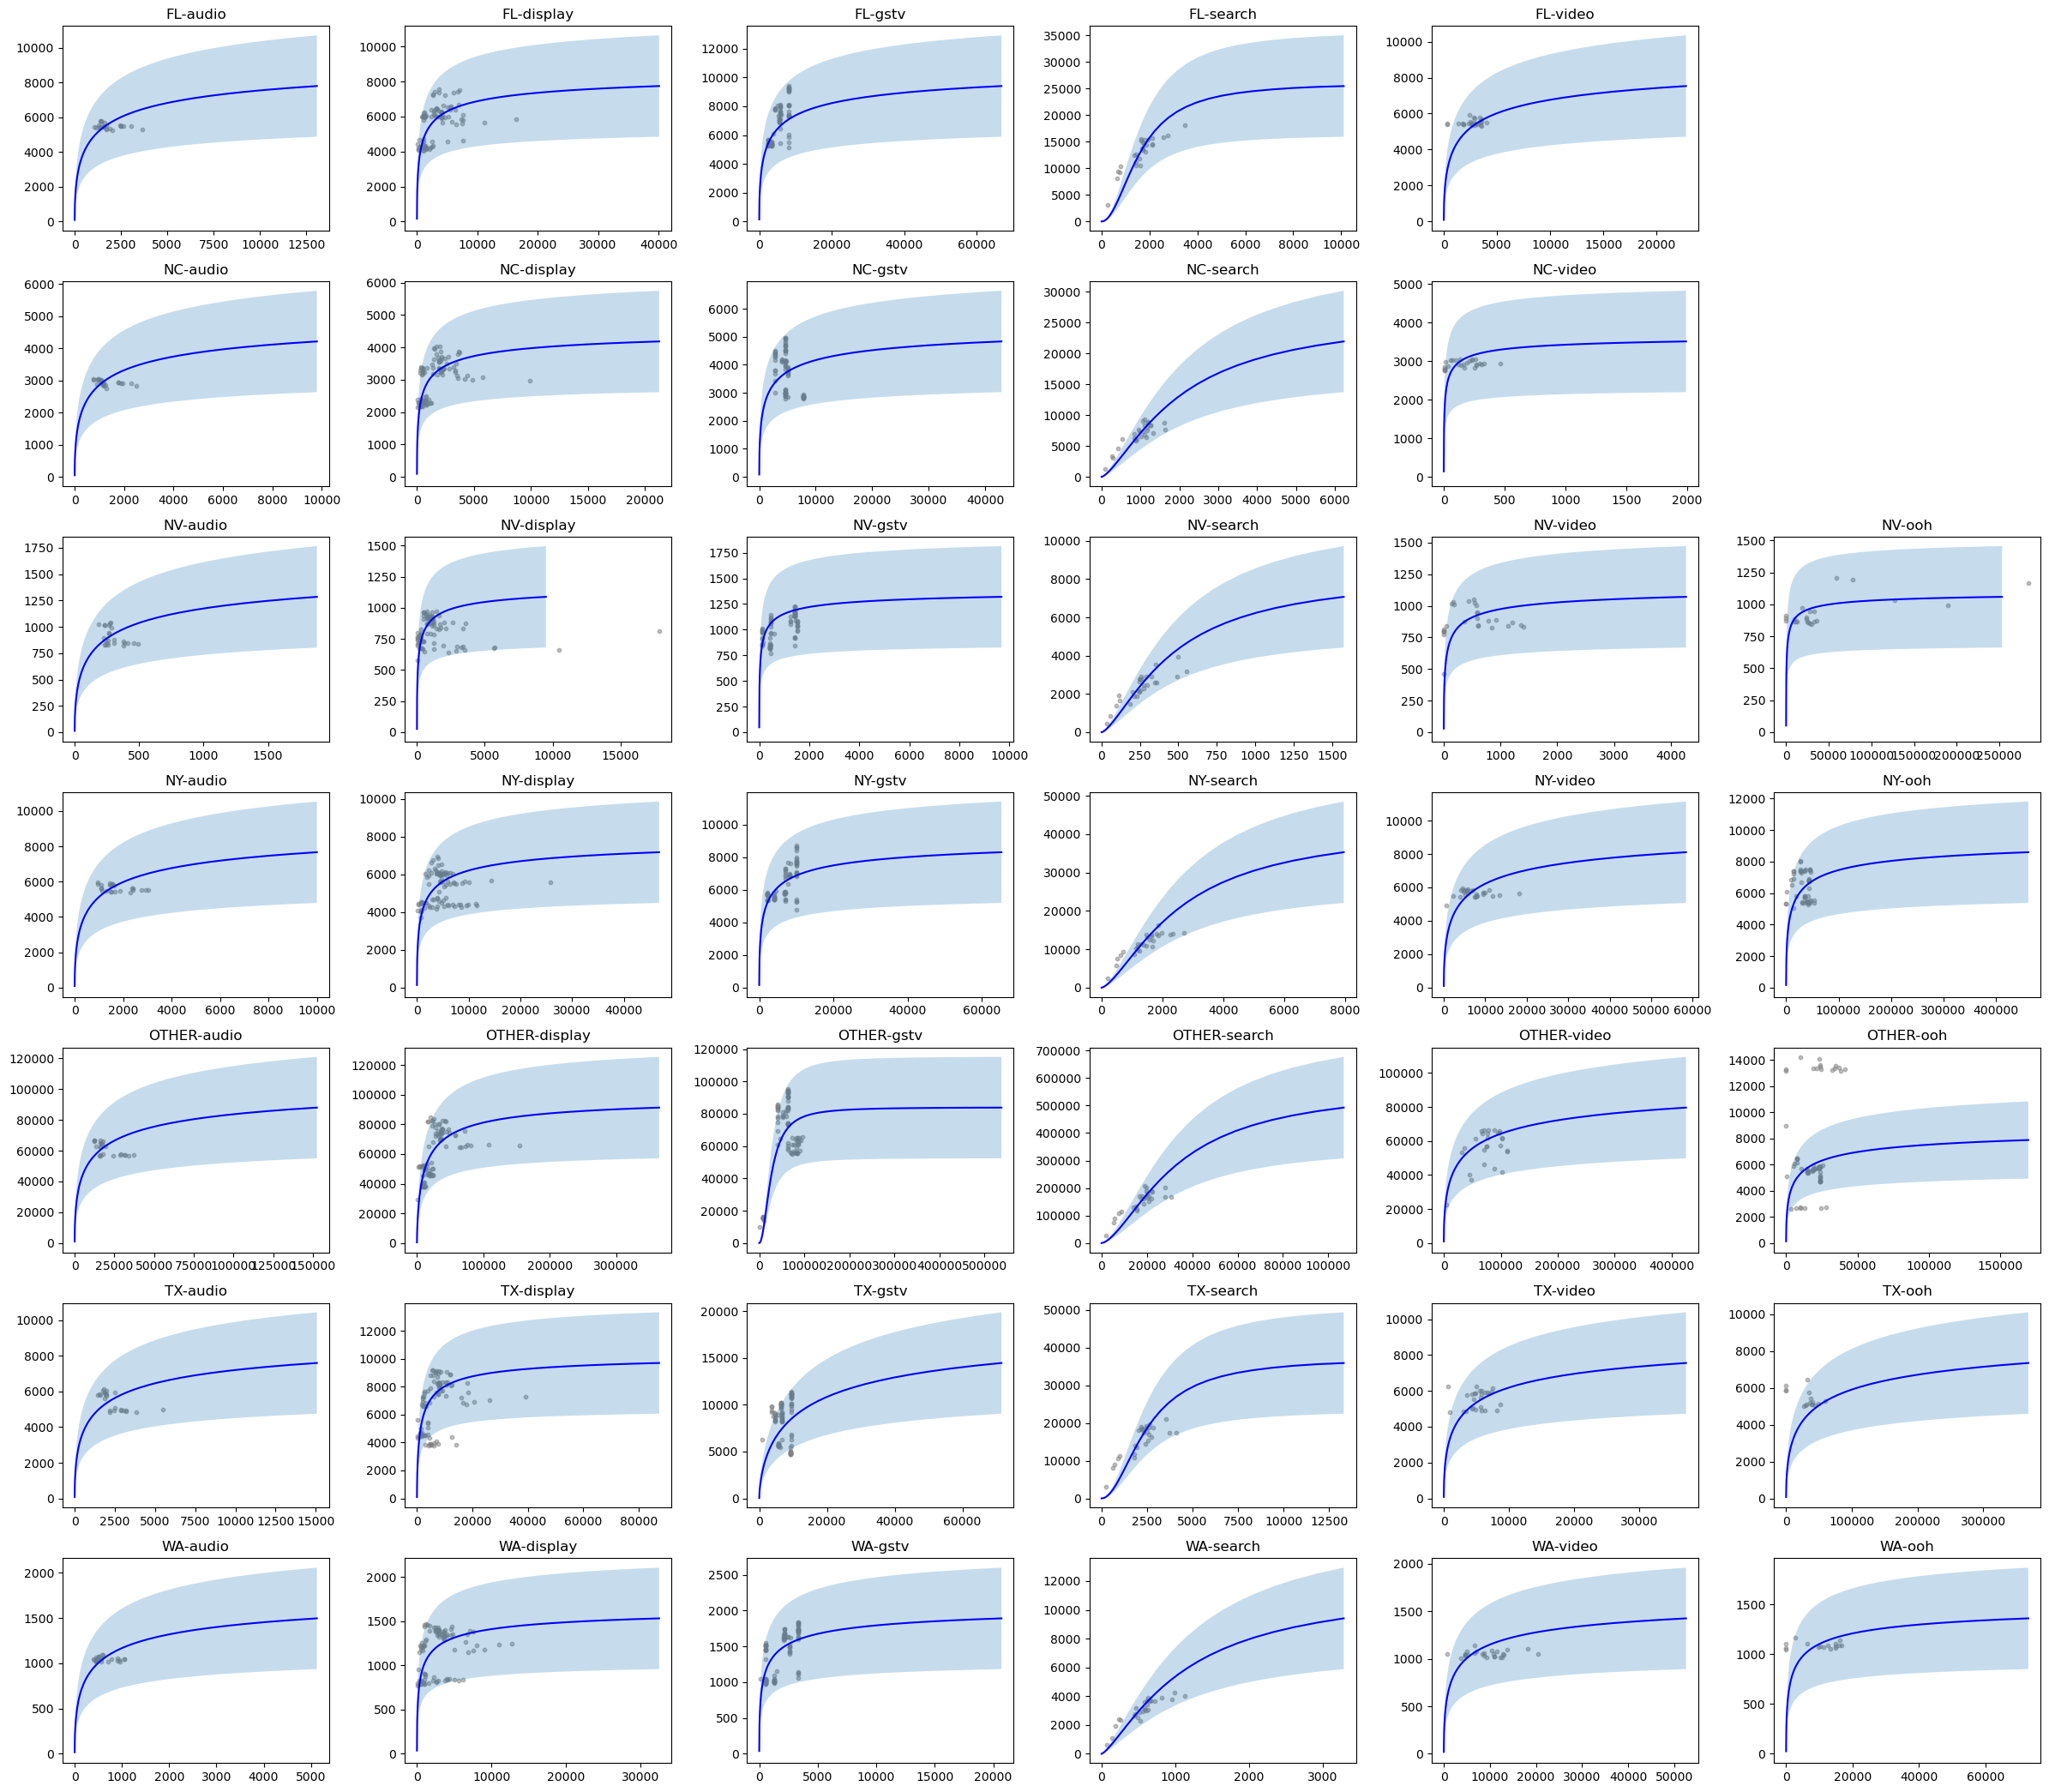

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter


def remove_outliers(df, low_q=0.1, high_q=0.9):

    spend_low  = df["spend"].quantile(low_q)
    spend_high = df["spend"].quantile(high_q)

    rev_low  = df["revenue"].quantile(low_q)
    rev_high = df["revenue"].quantile(high_q)

    return df[
        (df["spend"] >= spend_low) &
        (df["spend"] <= spend_high) &
        (df["revenue"] >= rev_low) &
        (df["revenue"] <= rev_high)
    ]



############################################
# CHANNEL DEFINITIONS
############################################

channels = {

"audio":("audio_revenue","Audio_impressions","Audio_spends"),
"display":("display_revenue","Display_impressions","Display_spends"),
"video":("video_revenue","Video_impressions","Video_spends"),
"gstv":("gstv_revenue","GSTV_impressions","GSTV_spends"),
"ooh":("ooh_revenue","OOH_impressions","OOH_spends"),

"search":("search_revenue","Search_clicks","Search_spends"),

}


############################################
# LONG FORMAT DATA
############################################

rows = []

for ch,(rev_col,input_col,spend_col) in channels.items():

    tmp = df[
        ["week_start_date","state_code",rev_col,input_col,spend_col]
    ].copy()

    tmp.columns = ["week","state","revenue","input","spend"]

    tmp["channel"] = ch

    rows.append(tmp)


long_df = pd.concat(rows)


############################################
# REMOVE ZERO SIGNAL ROWS
############################################

long_df = long_df[
    (long_df["input"]>0) &
    (long_df["revenue"]>0)
]


############################################
# STATE GROUPING
############################################

priority_states = ["NY","TX","WA","NV","NC","FL"]

long_df["geo"] = np.where(
    long_df["state"].isin(priority_states),
    long_df["state"],
    "OTHER"
)


############################################
# AGGREGATE DATA
############################################

agg_df = (
    long_df
    .groupby(["geo","channel","week"])
    .agg({
        "input":"sum",
        "revenue":"sum",
        "spend":"sum"
    })
    .reset_index()
)


############################################
# HILL FUNCTION
############################################

def hill(x,a,b,c):

    return a * (x**b) / (c**b + x**b)


############################################
# FIT FUNCTION
############################################

def fit_hill_curve(x,y):

    try:

        params,_ = curve_fit(
            hill,
            x,
            y,
            bounds=(
                [0,0.5,x.min()],
                [y.max()*3,2.0,x.max()*5]
            ),
            maxfev=20000
        )

        return params

    except:

        return None


############################################
# GRID GENERATION
############################################

def spend_grid(x):

    return np.concatenate([

        np.linspace(0,x.max()*0.05,30),

        np.logspace(
            np.log10(x.max()*0.05+1),
            np.log10(x.max()*5),   # ← extend curve
            40
        )

    ])


############################################
# FIT RESPONSE CURVES
############################################

curves = []

for (geo,ch),g in agg_df.groupby(["geo","channel"]):

    # Stronger filtering for problematic curves
    if (geo=="NV" and ch in ["video","ooh"]) or (geo=="TX" and ch=="ooh"):
        g = remove_outliers(g,0.2,0.8)
    else:
        g = remove_outliers(g,0.1,0.9)


    if len(g) < 6:
        continue

    x = g["input"].values
    y = g["revenue"].values

    params = fit_hill_curve(x,y)

    if params is None:
        continue

    a,b,c = params

    grid = spend_grid(x)

    pred = hill(grid,a,b,c)

    curves.append(pd.DataFrame({

        "geo":geo,
        "channel":ch,
        "input":grid,
        "mean_revenue":pred

    }))


curve_df = pd.concat(curves).reset_index(drop=True)


############################################
# ADD CREDIBLE INTERVAL
############################################

log_pre = posterior["log_media_pre"].values.flatten()
dlog = posterior["dlog_media"].values.flatten()

beta = np.exp(log_pre + dlog)

ci_ratio = beta.std() / beta.mean()

curve_df["p5"] = curve_df["mean_revenue"]*(1-ci_ratio)
curve_df["p95"] = curve_df["mean_revenue"]*(1+ci_ratio)


############################################
# CONVERT INPUT → SPEND
############################################

for ch,(rev_col,input_col,spend_col) in channels.items():

    mask = curve_df["channel"]==ch

    valid = df[input_col] > 0

    if "impressions" in input_col.lower():

        cpm = np.median(
            df.loc[valid,spend_col] /
            (df.loc[valid,input_col]/1000)
        )

        curve_df.loc[mask,"spend"] = (
            curve_df.loc[mask,"input"]/1000 * cpm
        )

    else:

        cpc = np.median(
            df.loc[valid,spend_col] /
            df.loc[valid,input_col]
        )

        curve_df.loc[mask,"spend"] = (
            curve_df.loc[mask,"input"] * cpc
        )


############################################
# SMOOTHING
############################################

def smooth(x):

    if len(x)>=7:
        return savgol_filter(x,7,2)

    return x


curve_df["mean_revenue"] = curve_df.groupby(
["geo","channel"]
)["mean_revenue"].transform(smooth)


############################################
# ENSURE MONOTONIC CURVE
############################################

curve_df["mean_revenue"] = curve_df.groupby(
["geo","channel"]
)["mean_revenue"].cummax()


############################################
# FINAL DATA FOR OPTIMIZER
############################################

optimizer_df = curve_df[[
"geo",
"channel",
"spend",
"mean_revenue",
"p5",
"p95"
]]


################################################
# PLOT RESPONSE CURVES
#################################################

geos = optimizer_df["geo"].unique()
channels_list = optimizer_df["channel"].unique()

fig,axes = plt.subplots(
    len(geos),
    len(channels_list),
    figsize=(4*len(channels_list),3*len(geos))
)

for i,geo in enumerate(geos):
    for j,ch in enumerate(channels_list):

        ax = axes[i,j]

        data = agg_df[
            (agg_df.geo==geo) &
            (agg_df.channel==ch)
        ]

        curve = optimizer_df[
            (optimizer_df.geo==geo) &
            (optimizer_df.channel==ch)
        ]

        if len(curve)==0:
            ax.axis("off")
            continue

        ax.scatter(
            data["spend"],
            data["revenue"],
            color="gray",
            s=10,
            alpha=0.5
        )

        ax.plot(
            curve["spend"],
            curve["mean_revenue"],
            color="blue"
        )

        ax.fill_between(
            curve["spend"],
            curve["p5"],
            curve["p95"],
            alpha=0.25
        )

        ax.set_title(f"{geo}-{ch}")

plt.tight_layout()
plt.show()

In [54]:
############################################
# REMOVE BAD GEO-CHANNEL COMBINATIONS
############################################

drop_pairs = [
    ("FL","ooh"),
    ("NC","ooh")
]

agg_df = agg_df[
    ~agg_df[["geo","channel"]]
    .apply(tuple,axis=1)
    .isin(drop_pairs)
]

In [68]:
############################################
# CURRENT MONTHLY SPEND
############################################

weekly_spend = (
    agg_df
    .groupby(["geo","channel"])
    ["spend"]
    .mean()
    .reset_index()
)

weekly_spend["current_spend"] = weekly_spend["spend"] * 4.33

current_spend_df = weekly_spend[["geo","channel","current_spend"]].copy()

current_spend_df["lower_pct"] = -10
current_spend_df["upper_pct"] = 10

current_spend_df["freeze"] = False

total_budget_default = current_spend_df["current_spend"].sum()

# current_spend_df

In [69]:
def human_format(num):

    if abs(num) >= 1_000_000:
        return f"{num/1_000_000:.2f}M"
    elif abs(num) >= 1_000:
        return f"{num/1_000:.2f}K"
    else:
        return f"{num:.0f}"
    
def apply_bounds(df):

    df = df.copy()

    df["lower_bound"] = df["current_spend"] * (1 + df["lower_pct"]/100)
    df["upper_bound"] = df["current_spend"] * (1 + df["upper_pct"]/100)

    return df


def parse_human_number(x):

    if isinstance(x,str):

        if "M" in x:
            return float(x.replace("M","")) * 1_000_000

        if "K" in x:
            return float(x.replace("K","")) * 1_000

    return float(x)

In [70]:
import ipywidgets as widgets
from IPython.display import display
import ipysheet
import pandas as pd
from IPython.display import display

budget_widget = widgets.FloatText(
    value=total_budget_default,
    description="Total Budget",
    style={"description_width":"150px"},
    layout=widgets.Layout(width="300px")
)

display_df = current_spend_df.copy()

display_df["current_spend"] = display_df["current_spend"].apply(human_format)

sheet = ipysheet.from_dataframe(display_df)

display(budget_widget)
display(sheet)


# sheet = ipysheet.from_dataframe(current_spend_df)

# display(budget_widget)
# display(sheet)

# display(budget_widget)
# display(current_spend_df)

FloatText(value=1846089.1023494666, description='Total Budget', layout=Layout(width='300px'), style=Descriptio…

Sheet(cells=(Cell(column_end=0, column_start=0, numeric_format=None, row_end=39, row_start=0, squeeze_row=Fals…

In [71]:
updated_spend_df = ipysheet.to_dataframe(sheet)

updated_spend_df["current_spend"] = (
    updated_spend_df["current_spend"]
    .apply(parse_human_number)
)

In [72]:
############################################
# BUILD INTERPOLATORS
############################################

from scipy.interpolate import interp1d

curve_functions = {}

for (geo,ch),g in optimizer_df.groupby(["geo","channel"]):

    g = g.sort_values("spend")

    curve_functions[(geo,ch)] = {

        "mean": interp1d(
            g["spend"], g["mean_revenue"],
            bounds_error=False,
            fill_value="extrapolate"
        ),

        "p5": interp1d(
            g["spend"], g["p5"],
            bounds_error=False,
            fill_value="extrapolate"
        ),

        "p95": interp1d(
            g["spend"], g["p95"],
            bounds_error=False,
            fill_value="extrapolate"
        )
    }

In [73]:
############################################
# RUN OPTIMIZER
############################################
updated_spend_df = apply_bounds(updated_spend_df)

optimized_spend = optimize_budget(
    updated_spend_df,
    budget_widget.value
)


results = current_spend_df.copy()

results["optimized_spend"] = optimized_spend

results["spend_change"] = (
    results["optimized_spend"] -
    results["current_spend"]
)

results["pct_change"] = (
    results["spend_change"] /
    results["current_spend"] * 100
)

In [74]:
############################################
# REVENUE + ROI
############################################

current_rev = []
opt_rev = []
p5_rev = []
p95_rev = []

for _,r in results.iterrows():

    geo = r["geo"]
    ch = r["channel"]

    f_mean = curve_functions[(geo,ch)]["mean"]
    f_p5 = curve_functions[(geo,ch)]["p5"]
    f_p95 = curve_functions[(geo,ch)]["p95"]

    current_rev.append(float(f_mean(r["current_spend"])))
    opt_rev.append(float(f_mean(r["optimized_spend"])))

    p5_rev.append(float(f_p5(r["optimized_spend"])))
    p95_rev.append(float(f_p95(r["optimized_spend"])))

results["current_revenue"] = current_rev
results["optimized_revenue"] = opt_rev

results["current_roi"] = (
    results["current_revenue"] /
    results["current_spend"]
)

results["optimized_roi"] = (
    results["optimized_revenue"] /
    results["optimized_spend"]
)

results

,geo,channel,current_spend,lower_pct,upper_pct,freeze,optimized_spend,spend_change,pct_change,current_revenue,optimized_revenue,current_roi,optimized_roi
0,FL,audio,7922.031166,-10,10,False,9503.999998,1581.968831,19.969233,7310.201847,7491.548553,0.922769,0.788252
1,FL,display,14102.687503,-10,10,False,14116.062128,13.374625,0.094837,7131.823662,7132.447235,0.505707,0.505272
2,FL,gstv,23480.902410,-10,10,False,23220.290989,-260.611421,-1.109887,8396.524767,8384.898697,0.357590,0.361102
3,FL,search,7187.865198,-10,10,False,7909.000000,721.134802,10.032670,24865.638290,25085.520197,3.459391,3.171769
4,FL,video,11425.634938,-10,10,False,12573.000000,1147.365062,10.042025,6902.028126,6996.474599,0.604083,0.556468
5,NC,audio,5584.947522,-10,10,False,6137.999999,553.052478,9.902555,3929.724358,3980.750155,0.703628,0.648542
6,NC,display,7099.310550,-10,10,False,7153.438165,54.127615,0.762435,3861.736893,3864.512600,0.543959,0.540231
7,NC,gstv,20936.460553,-10,10,False,19512.851346,-1423.609207,-6.799665,4540.224150,4507.178043,0.216857,0.230985
8,NC,search,4226.035138,-10,10,False,4653.000000,426.964862,10.103202,19534.847497,20203.031169,4.622500,4.341937
9,NC,video,695.574273,-10,10,False,765.600000,70.025727,10.067326,3372.677249,3388.211779,4.848767,4.425564


In [60]:
############################################
# REVENUE SUMMARY
############################################

current_total_rev = results["current_revenue"].sum()
opt_total_rev = results["optimized_revenue"].sum()

lift = opt_total_rev - current_total_rev
lift_pct = lift / current_total_rev * 100

summary = pd.DataFrame({

"metric":[
"Current Revenue",
"Optimized Revenue",
"Revenue Lift",
"Lift %"
],

"value":[
current_total_rev,
opt_total_rev,
lift,
lift_pct
]

})

summary

,metric,value
0,Current Revenue,1.046725e+06
1,Optimized Revenue,1.064045e+06
2,Revenue Lift,1.732058e+04
3,Lift %,1.654740e+00


In [75]:
############################################
# STATE SHIFT
############################################

state_shift = (
    results
    .groupby("geo")
    [["current_spend","optimized_spend"]]
    .sum()
)

state_shift["change"] = (
    state_shift["optimized_spend"] -
    state_shift["current_spend"]
)

state_shift

,current_spend,optimized_spend,change
geo,,,
FL,64119.121216,67322.353115,3203.231899
NC,38542.328037,38222.889511,-319.438526
NV,218137.728322,216945.942831,-1191.785491
NY,239487.066137,235677.631128,-3809.435009
OTHER,937362.069094,944816.534420,7454.465326
TX,239806.003122,239994.559363,188.556241
WA,108634.786422,103109.191974,-5525.594448


In [76]:
############################################
# CHANNEL SHIFT
############################################

channel_shift = (
    results
    .groupby("channel")
    [["current_spend","optimized_spend"]]
    .sum()
)

channel_shift["change"] = (
    channel_shift["optimized_spend"] -
    channel_shift["current_spend"]
)

channel_shift

,current_spend,optimized_spend,change
channel,,,
audio,123028.851371,130483.135875,7454.284504
display,215697.988815,215240.934379,-457.054436
gstv,358370.662246,354902.680569,-3467.981677
ooh,607275.995891,596052.552995,-11223.442896
search,106615.671231,117293.000000,10677.328769
video,435099.932796,432116.798523,-2983.134273


In [92]:
def run_optimizer(b):

    with output_area:
        
        clear_output()

        # get updated table from UI
        updated_spend_df = ipysheet.to_dataframe(sheet)

        # convert spend back to numeric
        updated_spend_df["current_spend"] = (
            updated_spend_df["current_spend"]
            .apply(parse_human_number)
        )

        # convert percent bounds to spend bounds
        updated_spend_df = apply_bounds(updated_spend_df)

        # run optimizer
        optimized_spend = optimize_budget(
            updated_spend_df,
            budget_widget.value
        )

        results = updated_spend_df.copy()

        results["optimized_spend"] = optimized_spend

        results["spend_change"] = (
            results["optimized_spend"] -
            results["current_spend"]
        )

        results["pct_change"] = (
            results["spend_change"] /
            results["current_spend"] * 100
        )

        ############################################
        # REVENUE CALCULATION
        ############################################

        ############################################
        # REVENUE + UNCERTAINTY
        ############################################

        current_rev = []
        opt_rev = []
        opt_rev_p5 = []
        opt_rev_p95 = []

        for _,r in results.iterrows():

            geo = r["geo"]
            ch = r["channel"]

            f_mean = curve_functions[(geo,ch)]["mean"]
            f_p5 = curve_functions[(geo,ch)]["p5"]
            f_p95 = curve_functions[(geo,ch)]["p95"]

            current_rev.append(float(f_mean(r["current_spend"])))
            opt_rev.append(float(f_mean(r["optimized_spend"])))

            opt_rev_p5.append(float(f_p5(r["optimized_spend"])))
            opt_rev_p95.append(float(f_p95(r["optimized_spend"])))

        results["current_revenue"] = current_rev
        results["optimized_revenue"] = opt_rev
        results["optimized_revenue_p5"] = opt_rev_p5
        results["optimized_revenue_p95"] = opt_rev_p95
        results["current_roi"] = (
            results["current_revenue"] /
            results["current_spend"]
        )

        results["optimized_roi"] = (
            results["optimized_revenue"] /
            results["optimized_spend"]
        )
        
        
        ############################################
                # GEO SPEND SUMMARY
        ############################################
        geo_spend = (
            results
            .groupby("geo")[["current_spend","optimized_spend"]]
            .sum()
            .reset_index()
        )

        geo_spend["change"] = (
            geo_spend["optimized_spend"] -
            geo_spend["current_spend"]
        )

        total_row = pd.DataFrame({

            "geo":["TOTAL"],

            "current_spend":[geo_spend["current_spend"].sum()],

            "optimized_spend":[geo_spend["optimized_spend"].sum()],

            "change":[geo_spend["change"].sum()]

        })

        geo_spend = pd.concat([geo_spend,total_row],ignore_index=True)
        
        

        ############################################
        # SPEND SHIFT CHART (STATE)
        ############################################

        import matplotlib.pyplot as plt

        state_chart = geo_spend[geo_spend["geo"]!="TOTAL"]

        plt.figure(figsize=(8,4))

        plt.bar(
            state_chart["geo"],
            state_chart["change"]
        )

        plt.title("Spend Shift by State")
        plt.ylabel("Spend Change")
        plt.xlabel("State")

        plt.axhline(0)

        plt.show()
        

        ############################################
            # CHANNEL ALLOCATION
        ############################################

        channel_alloc = (
            results
            .groupby("channel")[["current_spend","optimized_spend"]]
            .sum()
        )

        channel_alloc.plot(
            kind="bar",
            figsize=(8,4)
        )

        plt.title("Channel Allocation: Current vs Optimized")
        plt.ylabel("Spend")

        plt.show()
                
        ############################################
        # SUMMARY
        ############################################
        ############################################
        # REVENUE SUMMARY WITH UNCERTAINTY
        ############################################

        current_total = results["current_revenue"].sum()
        opt_total = results["optimized_revenue"].sum()

        p5_total = results["optimized_revenue_p5"].sum()
        p95_total = results["optimized_revenue_p95"].sum()

        lift = opt_total - current_total
        lift_pct = lift / current_total * 100

        summary = pd.DataFrame({

            "Metric":[
                "Current Revenue",
                "Optimized Revenue (Mean)",
                "Optimized Revenue (P5)",
                "Optimized Revenue (P95)",
                "Revenue Lift",
                "Lift %"
            ],

            "Value":[
                current_total,
                opt_total,
                p5_total,
                p95_total,
                lift,
                lift_pct
            ]

        })

        ############################################
        # TOP DASHBOARD TABLES
        ############################################

        summary_out = widgets.Output()
        geo_out = widgets.Output()

        with summary_out:
            print("REVENUE SUMMARY")
            display(summary)

        with geo_out:
            print("SPEND BY STATE")
            display(geo_spend)

        display(widgets.HBox([summary_out, geo_out]))

        print("OPTIMIZATION RESULTS")
        display(results)

        ############################################
        # STATE SHIFT
        ############################################

        state_shift = (
            results
            .groupby("geo")
            [["current_spend","optimized_spend"]]
            .sum()
        )

        state_shift["change"] = (
            state_shift["optimized_spend"] -
            state_shift["current_spend"]
        )

        print("STATE SPEND SHIFT")
        display(state_shift)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

run_button = widgets.Button(
    description="Run Optimization",
    button_style="success",
    icon="play"
)

output_area = widgets.Output()



        
run_button.on_click(run_optimizer)

In [95]:
header = widgets.HBox([
    budget_widget,
    run_button
])

dashboard = widgets.VBox([

    widgets.HTML("<h2>MMM Budget Optimizer</h2>"),

    header,

    widgets.HTML("<b>Edit Bounds / Freeze Channels</b>"),

    sheet,

    output_area

])

display(dashboard)



In [ ]:
#Pending items
# 1. Response curve-- current spend and optimised spend
# 2. % input for budget
# 3. Freeze entire channel globaly
# 4. MROI Table
# 5. uncertainity percent
# 6. visualize the result in better way
# 7. channel simulator ( vary the spends on particular channel X state and get the corressponding revenue with uncertainity)
 #3. Reverse optimisation

In [109]:
############################################
# COMPUTE MROI FROM CURVES
############################################

mroi_list = []

for (geo,ch),g in optimizer_df.groupby(["geo","channel"]):

    g = g.sort_values("spend")

    spend = g["spend"].values
    revenue = g["mean_revenue"].values
    rev_p5 = g["p5"].values
    rev_p95 = g["p95"].values

    mroi = np.gradient(revenue) / np.gradient(spend)
    mroi_p5 = np.gradient(rev_p5) / np.gradient(spend)
    mroi_p95 = np.gradient(rev_p95) / np.gradient(spend)

    # Clip unrealistic spikes
    mroi = np.clip(mroi, 0, 5)
    mroi_p5 = np.clip(mroi_p5, 0, 5)
    mroi_p95 = np.clip(mroi_p95, 0, 5)

    g = g.copy()

    g["mroi"] = mroi
    g["mroi_p5"] = mroi_p5
    g["mroi_p95"] = mroi_p95

    mroi_list.append(g)

mroi_df = pd.concat(mroi_list).reset_index(drop=True)

In [122]:
############################################
# MROI SUMMARY TABLE
############################################

mroi_summary = []

for _,r in results.iterrows():

    geo = r["geo"]
    ch = r["channel"]

    g = mroi_df[
        (mroi_df.geo==geo) &
        (mroi_df.channel==ch)
    ]

    mroi_current = np.interp(
        r["current_spend"],
        g["spend"],
        g["mroi"]
    )

    mroi_opt = np.interp(
        r["optimized_spend"],
        g["spend"],
        g["mroi"]
    )

    mroi_p5 = np.interp(
        r["optimized_spend"],
        g["spend"],
        g["mroi_p5"]
    )

    mroi_p95 = np.interp(
        r["optimized_spend"],
        g["spend"],
        g["mroi_p95"]
    )

    mroi_summary.append({

        "geo":geo,
        "channel":ch,
        "current_spend":r["current_spend"],
        "optimized_spend":r["optimized_spend"],
        "mroi_current":mroi_current,
        "mroi_optimized":mroi_opt,
        "mroi_p5":mroi_p5,
        "mroi_p95":mroi_p95

    })

mroi_summary = pd.DataFrame(mroi_summary)

mroi_summary.to_clipboard()

In [111]:
############################################
# RESPONSE CURVE PLOT
############################################

def plot_response_curve(geo,channel):

    curve = optimizer_df[
        (optimizer_df.geo==geo) &
        (optimizer_df.channel==channel)
    ]

    r = results[
        (results.geo==geo) &
        (results.channel==channel)
    ].iloc[0]

    plt.figure(figsize=(6,4))

    plt.plot(
        curve["spend"],
        curve["mean_revenue"],
        label="Mean Curve"
    )

    plt.fill_between(
        curve["spend"],
        curve["p5"],
        curve["p95"],
        alpha=0.25,
        label="Uncertainty Band"
    )

    plt.scatter(
        r["current_spend"],
        r["current_revenue"],
        color="blue",
        s=80,
        label="Current Spend"
    )

    plt.scatter(
        r["optimized_spend"],
        r["optimized_revenue"],
        color="red",
        s=80,
        label="Optimized Spend"
    )

    plt.title(f"{geo} - {channel} Response Curve")

    plt.xlabel("Spend")
    plt.ylabel("Revenue")

    plt.legend()

    plt.show()

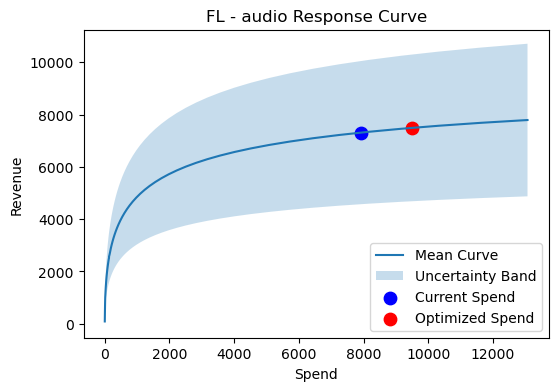

In [106]:
plot_response_curve("FL","audio")

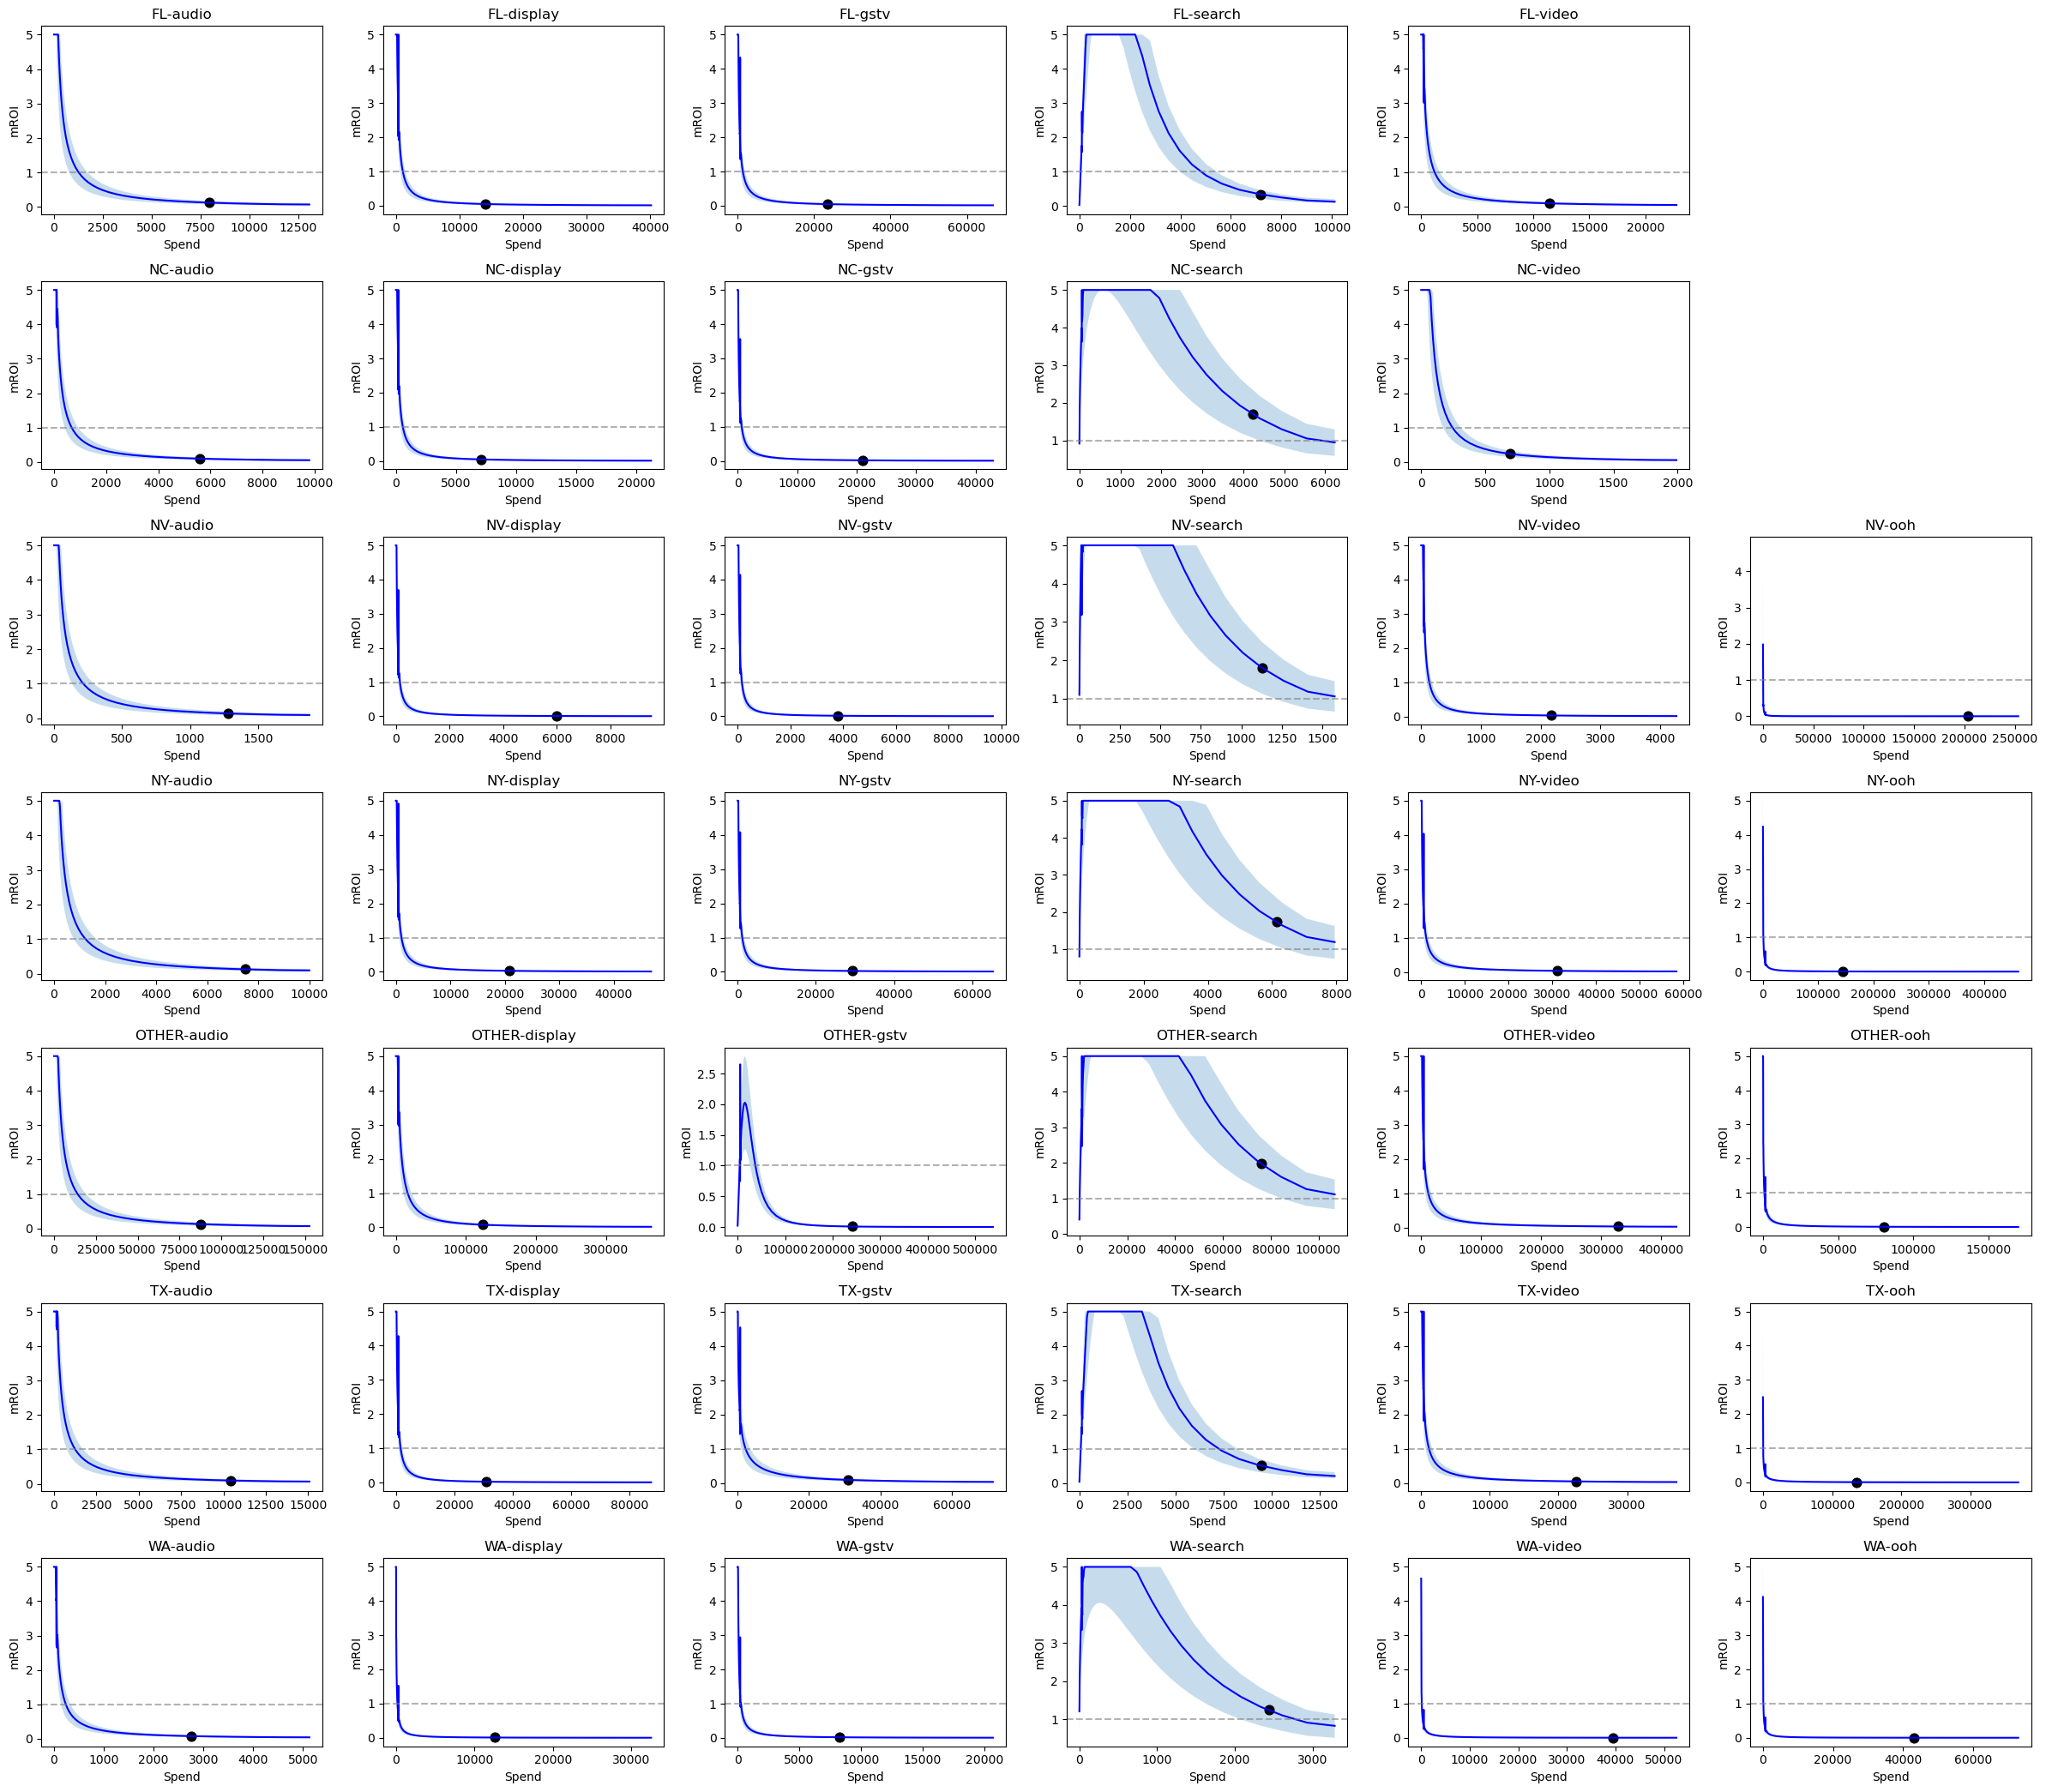

In [117]:
############################################
# MROI CURVE
############################################
############################################
# MROI GRID PLOT
############################################

geos = mroi_df["geo"].unique()
channels_list = mroi_df["channel"].unique()

fig, axes = plt.subplots(
    len(geos),
    len(channels_list),
    figsize=(4*len(channels_list),3*len(geos))
)

for i,geo in enumerate(geos):
    for j,ch in enumerate(channels_list):

        ax = axes[i,j]
        
        g = g[g["spend"] > g["spend"].max()*0.02]

        g = mroi_df[
            (mroi_df.geo==geo) &
            (mroi_df.channel==ch)
        ]

        r = results[
            (results.geo==geo) &
            (results.channel==ch)
        ]

        if len(g)==0:
            ax.axis("off")
            continue

        ###################################
        # mROI curve
        ###################################

        ax.plot(
            g["spend"],
            g["mroi"],
            color="blue"
        )

        ###################################
        # uncertainty band
        ###################################

        ax.fill_between(
            g["spend"],
            g["mroi_p5"],
            g["mroi_p95"],
            alpha=0.25
        )

        ###################################
        # current spend marker
        ###################################

        if len(r)>0:

            ax.scatter(
                r["current_spend"],
                np.interp(r["current_spend"], g["spend"], g["mroi"]),
                color="black",
                s=60,
                marker="o",
                label="Current"
            )
            
            ax.axhline(
                y=1,
                linestyle="--",
                color="gray",
                alpha=0.6
            )

            # ax.scatter(
            #     r["optimized_spend"],
            #     np.interp(r["optimized_spend"], g["spend"], g["mroi"]),
            #     color="red",
            #     s=80,
            #     marker="D",
            #     label="Optimized"
            # )

        ax.set_title(f"{geo}-{ch}")

        ax.set_xlabel("Spend")
        ax.set_ylabel("mROI")

plt.tight_layout()
plt.show()

In [120]:
############################################
# MROI TABLE (SPEND SENSITIVITY)
############################################

levels = [-0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5]

rows = []

for (geo,ch),g in mroi_df.groupby(["geo","channel"]):

    g = g.sort_values("spend")

    current_spend = results.loc[
        (results.geo==geo) &
        (results.channel==ch),
        "current_spend"
    ].values[0]

    row = {
        "geo":geo,
        "channel":ch
    }

    for lvl in levels:

        spend = current_spend * (1 + lvl)

        mroi_val = np.interp(
            spend,
            g["spend"],
            g["mroi"]
        )

        label = f"mROI_{int(lvl*100)}%" if lvl!=0 else "mROI_current"

        row[label] = mroi_val

    rows.append(row)

mroi_multiplier_table = pd.DataFrame(rows)

mroi_multiplier_table.to_clipboard()

In [126]:
############################################
# SPEND ELASTICITY TABLE
############################################

levels = [-0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5]

elasticity_rows = []

for (geo,ch),g in optimizer_df.groupby(["geo","channel"]):

    g = g.sort_values("spend")

    mroi_g = mroi_df[
        (mroi_df.geo==geo) &
        (mroi_df.channel==ch)
    ]

    current_spend = results.loc[
        (results.geo==geo) &
        (results.channel==ch),
        "current_spend"
    ].values[0]

    for lvl in levels:

        spend = current_spend * (1 + lvl)

        revenue = np.interp(
            spend,
            g["spend"],
            g["mean_revenue"]
        )

        mroi_val = np.interp(
            spend,
            mroi_g["spend"],
            mroi_g["mroi"]
        )

        roi = revenue / spend

        elasticity_rows.append({

            "geo":geo,
            "channel":ch,
            "spend_change_pct":lvl*100,
            "spend":spend,
            "revenue":revenue,
            "roi":roi,
            "mroi":mroi_val

        })

elasticity_table = pd.DataFrame(elasticity_rows)

elasticity_table.to_clipboard()